In [13]:
#Global Primary & Secondary Education Indicators Analysis

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [15]:
df = pd.read_csv(r"C:\Users\Samson\Desktop\Education Indicators Analysis.csv")
df.columns = df.columns.str.strip()

In [16]:
df["GDP_per_Capita"] = df["GDP"] / df["Population"]
df["Secondary_to_Primary_Ratio"] = (
    df["Enrolment in Secondary Education"]
    / df["Enrolment in Primary Education"]
)
df["Out_of_School_Rate"] = (
    df["Out-of-School Children of Primary School"] / df["Population"]
) * 100

In [17]:
# Drop rows where ALL columns are empty
df_cleaned = df.dropna(how="all")

In [18]:
df

,Country Name,Population,GDP,% of Repeaters in Primary Education,Out-of-School Children of Primary School,Enrolment in Secondary Education,Enrolment in Primary Education,Unemployment,Life Expectancy at Birth,Theoretical Duration of Primary Education,GDP_per_Capita,Secondary_to_Primary_Ratio,Out_of_School_Rate
0,Albania,2893654,1.321986e+10,0.73,7097,333291,195720,16.10,77.83,5,4568.568826,1.702897,0.245261
1,Arab World,384222592,2.890000e+12,6.42,6827541,30972246,45126932,11.52,70.57,6,7521.681599,0.686336,1.776975
2,United Arab Emirates,9086139,4.020000e+11,0.22,14611,411040,409776,3.60,77.37,5,44243.214857,1.003085,0.160805
3,Azerbaijan,9535079,7.519801e+10,0.16,22821,949294,517708,5.20,70.76,4,7886.459144,1.833648,0.239337
4,Burundi,10816860,3.093647e+09,24.25,69246,583308,2046794,6.90,56.69,6,286.002336,0.284986,0.640167
...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,Saharan Africa(IDA),974371891,1.770000e+12,8.18,34134436,56136952,158234432,7.97,58.56,6,1816.554866,0.354771,3.503225
103,Ukraine,45362900,1.340000e+11,0.06,56464,2713646,1685030,7.70,71.19,4,2953.955766,1.610444,0.124472
104,Upper middle income,2573612474,2.200000e+13,2.55,8831078,201880784,206630624,5.90,74.44,6,8548.295527,0.977013,0.343139
105,West Bank and Gaza,4294682,1.271560e+10,0.20,32849,709226,442476,26.20,72.90,4,2960.778001,1.602858,0.764876


In [20]:
#Top 10 Countries with Highest Primary Repetition Rates

top_repeaters = df.nlargest(10, "% of Repeaters in Primary Education")[
    ["Country Name", "% of Repeaters in Primary Education"]
]
print(top_repeaters)

           Country Name  % of Repeaters in Primary Education
4               Burundi                                24.25
70                 Mali                                20.06
100         Timor-Leste                                17.75
16        Cote d'Ivoire                                15.01
37               Guinea                                13.64
17             Cameroon                                12.73
82   Other small states                                11.51
34   Conflict affected                                 11.07
6                 Benin                                10.84
60           Low income                                10.24


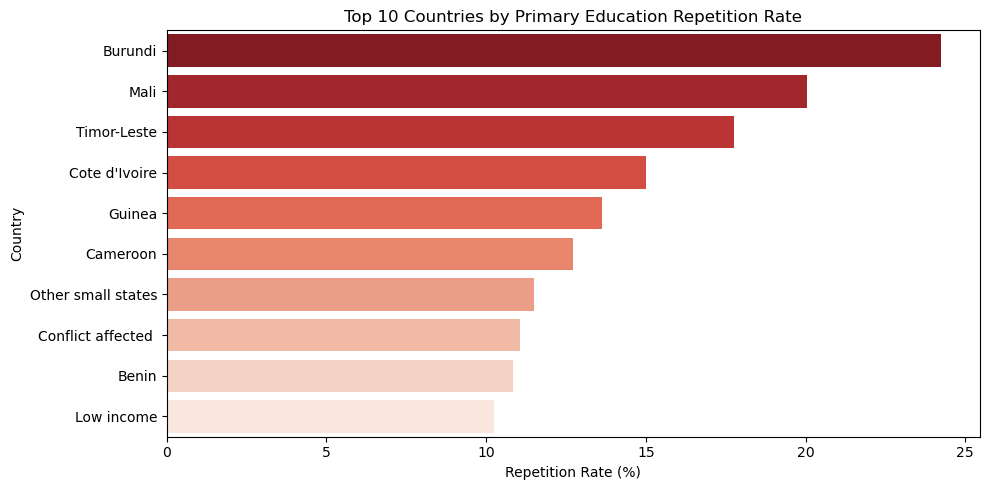

In [21]:
#Visualization

plt.figure(figsize=(10, 5))
sns.barplot(
    data=top_repeaters,
    x="% of Repeaters in Primary Education",
    y="Country Name",
    hue="Country Name",
    palette="Reds_r",
    legend=False,
)

plt.title("Top 10 Countries by Primary Education Repetition Rate")
plt.xlabel("Repetition Rate (%)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

In [25]:
#Secondary-to-Primary Enrolment Transition Ratio

df["Secondary_to_Primary_Ratio"] = (
    df["Enrolment in Secondary Education"]
    / df["Enrolment in Primary Education"]
)
clean_data = df["Secondary_to_Primary_Ratio"].replace(
    [np.inf, -np.inf], np.nan
).dropna()

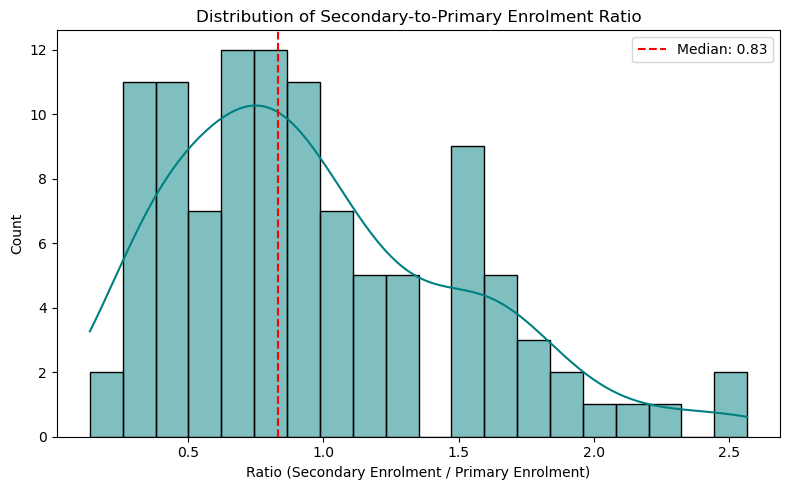

In [26]:
#Visualization

plt.figure(figsize=(8, 5))
sns.histplot(clean_data, kde=True, bins=20, color="teal")

plt.axvline(
    clean_data.median(),
    color="red",
    linestyle="--",
    label=f"Median: {clean_data.median():.2f}",
)

plt.title("Distribution of Secondary-to-Primary Enrolment Ratio")
plt.xlabel("Ratio (Secondary Enrolment / Primary Enrolment)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
#Out-of-School Children Ratio per Capita

top_out_of_school = df.nlargest(10, "Out_of_School_Rate")[
    ["Country Name", "Out_of_School_Rate"]
]
print(top_out_of_school)

                Country Name  Out_of_School_Rate
57                   Liberia           10.063677
78                     Niger            6.452598
70                      Mali            6.026400
7               Burkina Faso            5.439236
16             Cote d'Ivoire            3.966447
85  Pre-demographic dividend            3.949337
76                Mauritania            3.794666
34        Conflict affected             3.528000
91       Saharan Africa(-hi)            3.503507
92        Sub-Saharan Africa            3.503225


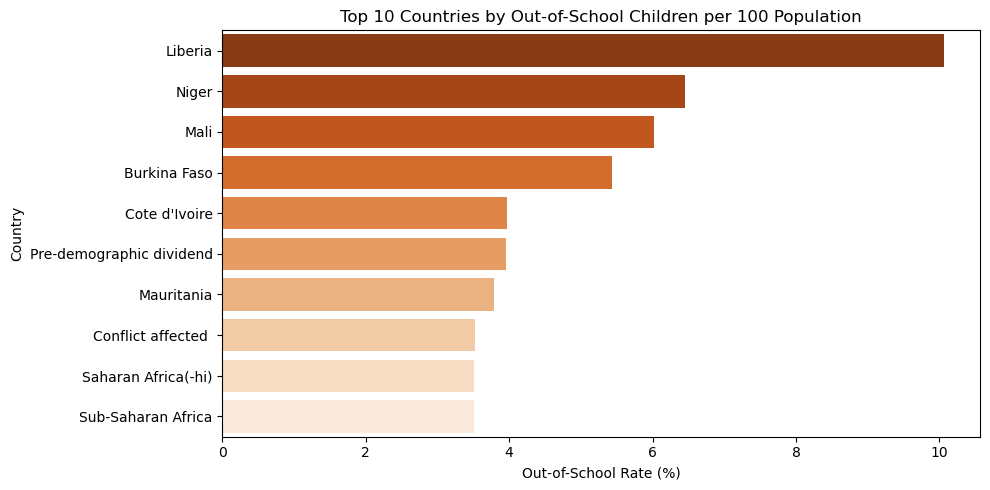

In [38]:
#Visualization

plt.figure(figsize=(10, 5))
sns.barplot(
    data=top_out_of_school,
    x="Out_of_School_Rate",
    y="Country Name",
    hue="Country Name",
    palette="Oranges_r",
    legend=False,
)

plt.title("Top 10 Countries by Out-of-School Children per 100 Population")
plt.xlabel("Out-of-School Rate (%)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

In [41]:
#Unemployment vs. Primary Grade Repetition

df["Unemployment_Quartile"] = pd.qcut(
    df["Unemployment"],
    q=4,
    labels=["Q1 (Lowest)", "Q2 (Low-Mid)", "Q3 (Mid-High)", "Q4 (Highest)"],
)

In [43]:
#Aggregate average repetition rate

grouped_df = (
    df.groupby("Unemployment_Quartile", observed=False)[
        "% of Repeaters in Primary Education"
    ]
    .mean()
    .reset_index()
)

C:\Users\Samson\AppData\Local\Temp\ipykernel_3028\3997761459.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


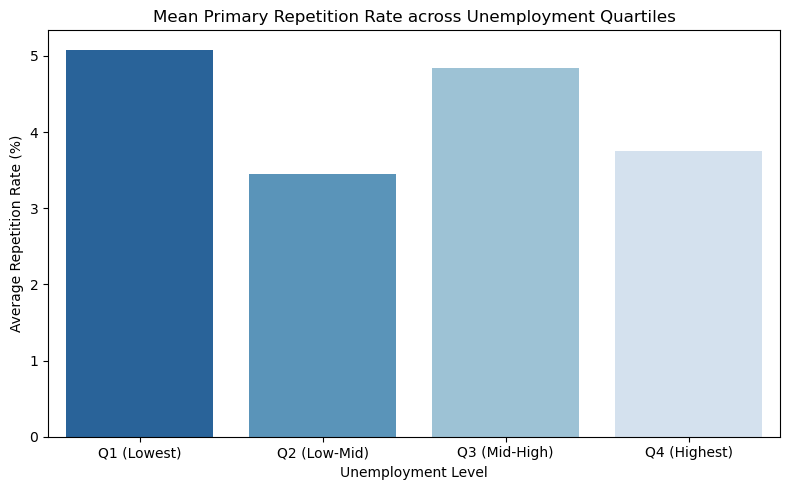

In [44]:
#Visualization

plt.figure(figsize=(8, 5))
sns.barplot(
    data=grouped_df,
    x="Unemployment_Quartile",
    y="% of Repeaters in Primary Education",
    palette="Blues_r",
)

plt.title("Mean Primary Repetition Rate across Unemployment Quartiles")
plt.xlabel("Unemployment Level")
plt.ylabel("Average Repetition Rate (%)")
plt.tight_layout()
plt.show()

In [48]:
#Primary Enrolment Coverage Rate

df["Primary_Enrolment_Pct"] = (
    df["Enrolment in Primary Education"] / df["Population"]
) * 100

In [50]:
top_coverage = df.nlargest(10, "Primary_Enrolment_Pct")[
    ["Country Name", "Primary_Enrolment_Pct"]
]
print(top_coverage)

                 Country Name  Primary_Enrolment_Pct
75                 Mozambique              20.831619
100               Timor-Leste              20.282615
6                       Benin              20.128637
4                     Burundi              18.922257
17                   Cameroon              18.191597
63                    Lesotho              17.354851
60                 Low income              16.986105
42      Poor countries (HIPC)              16.958103
85   Pre-demographic dividend              16.500436
91        Saharan Africa(-hi)              16.240255


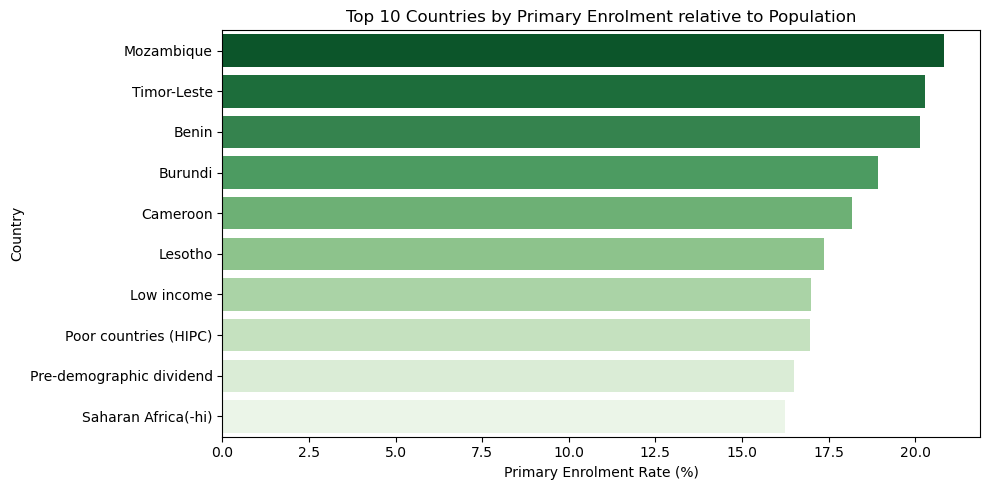

In [51]:
#Visualization

plt.figure(figsize=(10, 5))
sns.barplot(
    data=top_coverage,
    x="Primary_Enrolment_Pct",
    y="Country Name",
    hue="Country Name",
    palette="Greens_r",
    legend=False,
)

plt.title("Top 10 Countries by Primary Enrolment relative to Population")
plt.xlabel("Primary Enrolment Rate (%)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

In [52]:
#Out-of-School Children vs. Life Expectancy

df["Out_of_School_Rate"] = (
    df["Out-of-School Children of Primary School"] / df["Population"]
) * 100

In [54]:
#Life Expectancy logical tiers

df["Life_Expectancy_Tier"] = pd.cut(
    df["Life Expectancy at Birth"],
    bins=[0, 60, 70, 75, 100],
    labels=["< 60 Yrs", "60-70 Yrs", "70-75 Yrs", "> 75 Yrs"],
)

C:\Users\Samson\AppData\Local\Temp\ipykernel_3028\2330844841.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


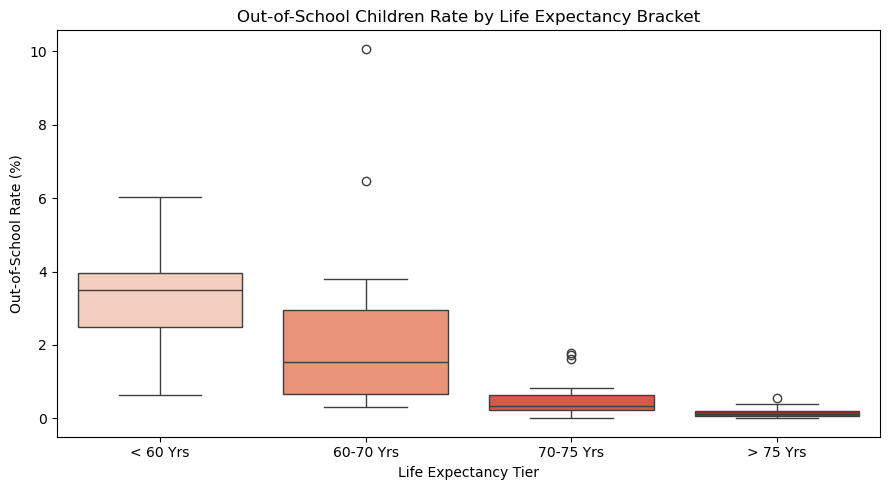

In [55]:
#Visualization

plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df,
    x="Life_Expectancy_Tier",
    y="Out_of_School_Rate",
    palette="Reds",
)

plt.title("Out-of-School Children Rate by Life Expectancy Bracket")
plt.xlabel("Life Expectancy Tier")
plt.ylabel("Out-of-School Rate (%)")
plt.tight_layout()
plt.show()

In [58]:
#Socio-Economic & Educational Correlation Heatmap

df["Out_of_School_Rate"] = (
    df["Out-of-School Children of Primary School"] / df["Population"]
) * 100

In [60]:
#numeric features for compute correlation matrix

numeric_cols = [
    "GDP_per_Capita",
    "% of Repeaters in Primary Education",
    "Unemployment",
    "Life Expectancy at Birth",
    "Secondary_to_Primary_Ratio",
    "Out_of_School_Rate",
]
corr_matrix = df[numeric_cols].corr()
print(numeric_cols)

['GDP_per_Capita', '% of Repeaters in Primary Education', 'Unemployment', 'Life Expectancy at Birth', 'Secondary_to_Primary_Ratio', 'Out_of_School_Rate']


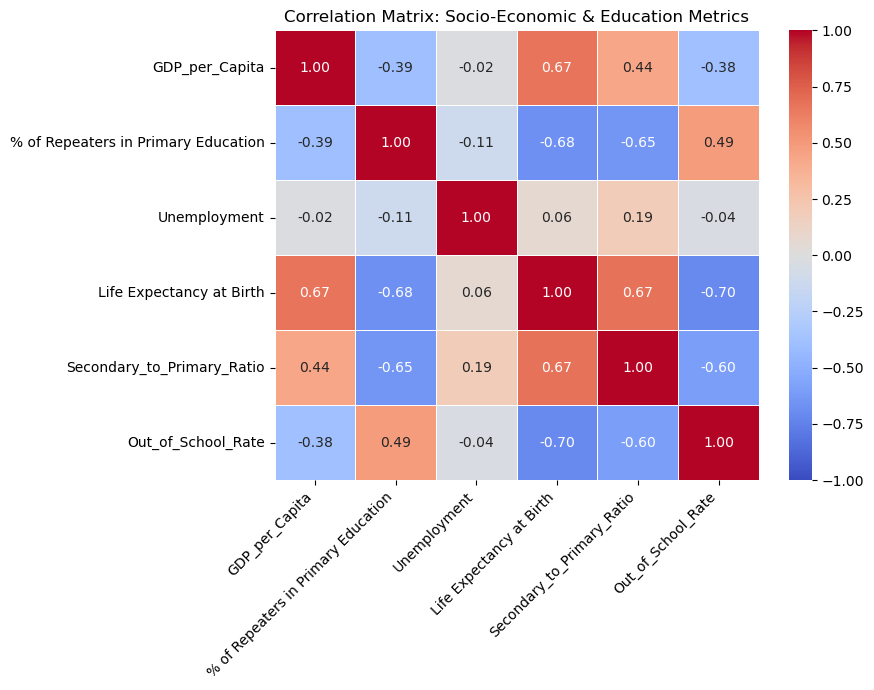

In [61]:
#Visualization

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1,  # Normalizes correlation scale between -1 and +1
)

plt.title("Correlation Matrix: Socio-Economic & Education Metrics")
plt.xticks(rotation=45, ha="right")  # Prevents label clipping on X-axis
plt.tight_layout()
plt.show()